# **Notebook 6: Fine-Tuning Pipeline**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `./tokenized_train/` + `./tokenized_valid/` — Created by Notebook 2
- [ ] GPU runtime enabled (T4 minimum)

**Files this notebook will CREATE:**
- [ ] `./intent_lora_best/` — Best LoRA checkpoint (by val loss) _(Required by NB7)_
- [ ] `./intent_lora/` — Final LoRA checkpoint _(Backup)_
- [ ] `training_log.csv` + `training_curves.png` — Evidence for report

---

In [2]:
%pip install -q peft

Note: you may need to restart the kernel to use updated packages.


## **Stage 4: Solution V2 (Fine-Tuned Retrieval-Assisted Generation)**

### **Task 4.1: Configure Fine-Tuning Pipeline**

#### **4.1.1 Configure PEFT Framework [3 marks]**
**The Task:** Apply LoRA (or QLoRA) to the model's `q_proj` and `v_proj` attention modules, set adapter settings and target modules, and prepare the training environment.

**Hints & Tips:**
* LoRA adds small trainable matrices to frozen attention layers — only ~0.5–1% of params update.
* `r=16` = rank of the low-rank matrices; `lora_alpha=32` scales them (rule of thumb: alpha = 2×r).
* `target_modules=["q_proj","v_proj"]`. Adding `["k_proj","o_proj"]` trains more params but may overfit on small data.
* Call `peft_model.print_trainable_parameters()` to confirm the tiny trainable %.

**LoRA Config Tuning:**
* `r`: 8 (lighter), **16 (recommended)**, 32 (more capacity).
* `lora_alpha`: usually 2×r → 16, **32**, 64.

**Learner Inference:** Updating only attention projections fundamentally changes behaviour (chat → JSON) using a fraction of the compute.

In [5]:
# YOUR CODE HERE
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

device = "mps" if torch.backends.mps.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float16,
).to(device)

print("Model loaded on:", model.device)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

Loading weights: 100%|██████████| 338/338 [00:03<00:00, 90.47it/s] 


Model loaded on: mps:0
trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


#### **4.1.2 Configure Training Parameters [2 marks]**
**The Task:** Define the learning rate, batch size, number of steps/epochs, optimisation strategy (AdamW), and quantisation settings.

**Hints & Tips:**
* Initialise `AdamW(filter(lambda p: p.requires_grad, peft_model.parameters()), lr=2e-4)`.
* Build `DataLoader`s for the train and validation sets (remember `set_format("torch", ...)` after `load_from_disk`).
* Define `VAL_EVERY` (e.g. 10 steps) and an early-stopping `PATIENCE` (e.g. 3) for the next task.

**Parameter Tuning:**
* `lr=2e-4` standard; try `1e-4` (slower) or `5e-4` (faster).
* `batch_size=4` fits T4; use 2 if OOM, 8 on A100.
* `max_steps=200`: ~25% of one epoch on 3200 rows. Increase to 400–500 for a full epoch.

**Learner Inference:** These hyperparameters control how fast and how stably the adapter learns the JSON-extraction task.

In [7]:
# YOUR CODE HERE
from datasets import load_from_disk
from torch.utils.data import DataLoader

train_ds = load_from_disk("./tokenized_train")
valid_ds = load_from_disk("./tokenized_valid")

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
valid_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Train examples:", len(train_ds))
print("Valid examples:", len(valid_ds))
print("One example keys:", train_ds[0].keys())


BATCH_SIZE = 4
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, peft_model.parameters()),
    lr=2e-4,
)

MAX_STEPS = 200
VAL_EVERY = 10
PATIENCE = 3

print("Batches per epoch:", len(train_loader))

Train examples: 3121
Valid examples: 390
One example keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
Batches per epoch: 781


### **Task 4.2: Train Fine-Tuned Model**

#### **4.2.1 Execute Fine-Tuning [5 marks]**
**The Task:** Run the custom PyTorch training loop. Monitor BOTH train and validation loss at regular intervals, implement early stopping based on validation loss, and plot the train-vs-validation loss curves.

**Hints & Tips:**
* The validation loop runs every `VAL_EVERY` steps under `torch.no_grad()` (no gradients).
* Early stopping: track `best_val_loss`; if it doesn't improve for `PATIENCE` checks, stop.
* The loss-curve plot is mandatory evidence — save it as `training_curves.png`.

**What to look for in the curve:**
* Both lines falling → learning, no overfitting.
* Val rises while train falls → overfitting (early stopping saves you).
* Both flat → LR too low or data too small.
* Val spikes → bad batch / instability.

**Learner Inference:** Falling loss proves gradient descent is teaching the JSON format. Validation monitoring prevents silent memorisation.

In [8]:
# YOUR CODE HERE
import itertools

def compute_loss(batch):
    batch = {k: v.to(device) for k, v in batch.items()}
    outputs = peft_model(**batch)
    return outputs.loss

peft_model.train()                       
best_val_loss = float("inf")           
patience_counter = 0                     
log = []                                 

train_iter = itertools.cycle(train_loader)
print("Setup done. Ready to train.")

Setup done. Ready to train.


In [9]:
# YOUR CODE HERE
@torch.no_grad()
def evaluate_validation():
    peft_model.eval()
    total_loss = 0.0
    for batch in valid_loader:
        loss = compute_loss(batch)
        total_loss += loss.item()
    peft_model.train()
    return total_loss / len(valid_loader)

# Main Training Loop
peft_model.train()

for step in range(1, MAX_STEPS + 1):
    batch = next(train_iter)
    train_loss = compute_loss(batch)

    train_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if step % VAL_EVERY == 0:
        val_loss = evaluate_validation()
        log.append((step, train_loss.item(), val_loss))
        print(f"Step {step:3d} | train {train_loss.item():.4f} | val {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            peft_model.save_pretrained("./intent_lora_best")
            patience_counter = 0
            print(f"          ↳ new best (val {val_loss:.4f}) — saved")
        else:
            patience_counter += 1
            print(f"          ↳ no improvement ({patience_counter}/{PATIENCE})")
            if patience_counter >= PATIENCE:
                print("Early stopping triggered.")
                break

print("Training finished. Best val loss:", round(best_val_loss, 4))

Step  10 | train 2.9582 | val 2.6564
          ↳ new best (val 2.6564) — saved
Step  20 | train 2.0290 | val 1.7834
          ↳ new best (val 1.7834) — saved
Step  30 | train 1.3862 | val 1.2314
          ↳ new best (val 1.2314) — saved
Step  40 | train 1.0842 | val 0.9972
          ↳ new best (val 0.9972) — saved
Step  50 | train 0.8084 | val 0.8528
          ↳ new best (val 0.8528) — saved
Step  60 | train 0.7852 | val 0.8066
          ↳ new best (val 0.8066) — saved
Step  70 | train 0.6991 | val 0.7758
          ↳ new best (val 0.7758) — saved
Step  80 | train 0.7252 | val 0.7429
          ↳ new best (val 0.7429) — saved
Step  90 | train 0.8059 | val 0.7120
          ↳ new best (val 0.7120) — saved
Step 100 | train 0.5916 | val 0.6925
          ↳ new best (val 0.6925) — saved
Step 110 | train 0.6842 | val 0.6689
          ↳ new best (val 0.6689) — saved
Step 120 | train 0.5331 | val 0.6445
          ↳ new best (val 0.6445) — saved
Step 130 | train 0.7734 | val 0.6429
          ↳ new

#### **4.2.2 Save Training Outputs [2 marks]**
**The Task:** Save the best checkpoint (by validation loss), document the checkpoint/model-saving workflow, and export reproducibility information.

**Hints & Tips:**
* Save two checkpoints: `./intent_lora_best/` (lowest val loss) and `./intent_lora/` (final step).
* Export a `training_log.csv` with columns `step, train_loss, val_loss`.
* Record reproducibility info: model ID, LoRA config, learning rate, batch size, seed.

**Learner Inference:** Saving the BEST checkpoint (not the last) ensures your final model is the one that generalised best, not one that started overfitting.

In [10]:
# YOUR CODE HERE
import csv, json

peft_model.save_pretrained("./intent_lora")
print("Saved final checkpoint → ./intent_lora/")

with open("training_log.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["step", "train_loss", "val_loss"])
    writer.writerows(log)
print("Saved training log → training_log.csv")

repro = {
    "model_id": MODEL_ID,
    "lora": {"r": 16, "alpha": 32, "target_modules": ["q_proj", "v_proj"],
             "dropout": 0.05},
    "learning_rate": 2e-4,
    "batch_size": BATCH_SIZE,
    "max_steps": MAX_STEPS,
    "best_val_loss": round(best_val_loss, 4),
    "device": device,
    "note": "LoRA on Apple Silicon MPS in float16 (QLoRA/4-bit bitsandbytes not supported on M1)",
}
with open("training_config.json", "w") as f:
    json.dump(repro, f, indent=2)
print("Saved reproducibility info → training_config.json")

Saved final checkpoint → ./intent_lora/
Saved training log → training_log.csv
Saved reproducibility info → training_config.json


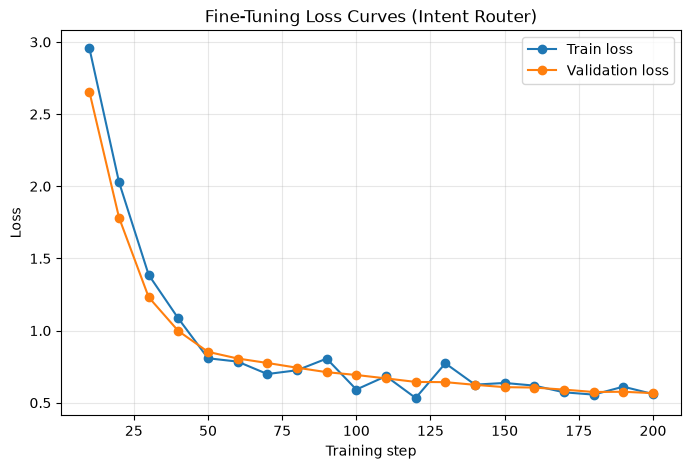

Saved loss curve → training_curves.png


In [11]:
import matplotlib.pyplot as plt

steps      = [row[0] for row in log]
train_loss = [row[1] for row in log]
val_loss   = [row[2] for row in log]

plt.figure(figsize=(8, 5))
plt.plot(steps, train_loss, marker="o", label="Train loss")
plt.plot(steps, val_loss,   marker="o", label="Validation loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Fine-Tuning Loss Curves (Intent Router)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved loss curve → training_curves.png")

---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify before proceeding to Notebook 7.**

- [ ] Tokenized train/valid loaded from disk (`set_format` re-applied)
- [ ] **4.1.1** LoRA configured targeting `q_proj`/`v_proj`
- [ ] **4.1.2** Optimizer + training params + dataloaders set
- [ ] **4.2.1** Training loop run with val monitoring + early stopping + loss curve
- [ ] **4.2.2** Best checkpoint saved + reproducibility info recorded
- [ ] **`./intent_lora_best/` saved** ← _CRITICAL for NB7_
- [ ] **`training_log.csv` + `training_curves.png` saved** ← _Evidence_

**If any item is unchecked, fix it before moving on.**